# 02 — NLP Feature Extraction
Two approaches compared:
- **Approach A:** TF-IDF bag-of-words features from job descriptions
- **Approach B:** LLM-extracted structured fields (seniority, skills, domain) via prompt engineering with OpenAI GPT-4o-mini

In [2]:
import sys
!{sys.executable} -m pip install openai

  Using cached openai-2.41.0-py3-none-any.whl.metadata (32 kB)
  Using cached jiter-0.15.0-cp312-cp312-win_amd64.whl.metadata (5.3 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
Using cached openai-2.41.0-py3-none-any.whl (1.4 MB)
Using cached jiter-0.15.0-cp312-cp312-win_amd64.whl (197 kB)
Using cached typing_extensions-4.15.0-py3-none-any.whl (44 kB)
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.11.0
    Uninstalling typing_extensions-4.11.0:
      Successfully uninstalled typing_extensions-4.11.0


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import pickle
import json
import os
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

os.makedirs('../src', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../docs/figures', exist_ok=True)
os.makedirs('../docs', exist_ok=True)

## 1. Load Data

In [5]:
df = pd.read_csv('../data/processed/job_postings_clean.csv')
df_desc = pd.read_csv('../data/raw/job_descriptions.csv')
print(f'Postings: {df.shape}')
print(f'Job Descriptions dataset: {df_desc.shape}')
df_desc.head(2)

Postings: (26866, 8)
Job Descriptions dataset: (1615940, 23)


,Job Id,Experience,Qualifications,Salary Range,location,Country,latitude,longitude,Work Type,Company Size,...,Contact,Job Title,Role,Job Portal,Job Description,Benefits,skills,Responsibilities,Company,Company Profile
0,1089843540111562,5 to 15 Years,M.Tech,$59K-$99K,Douglas,Isle of Man,54.2361,-4.5481,Intern,26801,...,001-381-930-7517x737,Digital Marketing Specialist,Social Media Manager,Snagajob,Social Media Managers oversee an organizations...,"{'Flexible Spending Accounts (FSAs), Relocatio...","Social media platforms (e.g., Facebook, Twitte...","Manage and grow social media accounts, create ...",Icahn Enterprises,"{""Sector"":""Diversified"",""Industry"":""Diversifie..."
1,398454096642776,2 to 12 Years,BCA,$56K-$116K,Ashgabat,Turkmenistan,38.9697,59.5563,Intern,100340,...,461-509-4216,Web Developer,Frontend Web Developer,Idealist,Frontend Web Developers design and implement u...,"{'Health Insurance, Retirement Plans, Paid Tim...","HTML, CSS, JavaScript Frontend frameworks (e.g...","Design and code user interfaces for websites, ...",PNC Financial Services Group,"{""Sector"":""Financial Services"",""Industry"":""Com..."


## 2. Text Preprocessing

In [7]:
def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

df['description_clean'] = df['description'].apply(clean_text)
print('Sample cleaned text:')
print(df['description_clean'].iloc[0][:300])

Sample cleaned text:
job descriptiona leading real estate firm in new jersey is seeking an administrative marketing coordinator with some experience in graphic design you will be working closely with our fun kind ambitious members of the sales team and our dynamic executive team on a daily basis this is an opportunity t


## 3. Approach A — TF-IDF Features

In [9]:
tfidf = TfidfVectorizer(
    max_features=200,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=5
)

tfidf_matrix = tfidf.fit_transform(df['description_clean'])
print(f'TF-IDF matrix shape: {tfidf_matrix.shape}')

svd = TruncatedSVD(n_components=30, random_state=42)
tfidf_reduced = svd.fit_transform(tfidf_matrix)
print(f'Reduced shape: {tfidf_reduced.shape}')
print(f'Variance explained: {svd.explained_variance_ratio_.sum():.2%}')

TF-IDF matrix shape: (26866, 200)
Reduced shape: (26866, 30)
Variance explained: 47.60%


In [10]:
# Top 20 keywords overall
feature_names = tfidf.get_feature_names_out()
mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
top_idx = mean_tfidf.argsort()[-20:][::-1]
print('Top 20 TF-IDF terms:')
for i in top_idx:
    print(f'  {feature_names[i]}: {mean_tfidf[i]:.4f}')

Top 20 TF-IDF terms:
  experience: 0.1075
  work: 0.0896
  team: 0.0749
  skills: 0.0635
  business: 0.0626
  management: 0.0613
  including: 0.0572
  sales: 0.0571
  job: 0.0566
  company: 0.0566
  benefits: 0.0542
  support: 0.0541
  ability: 0.0538
  time: 0.0538
  data: 0.0528
  position: 0.0528
  customer: 0.0516
  required: 0.0512
  project: 0.0502
  role: 0.0496


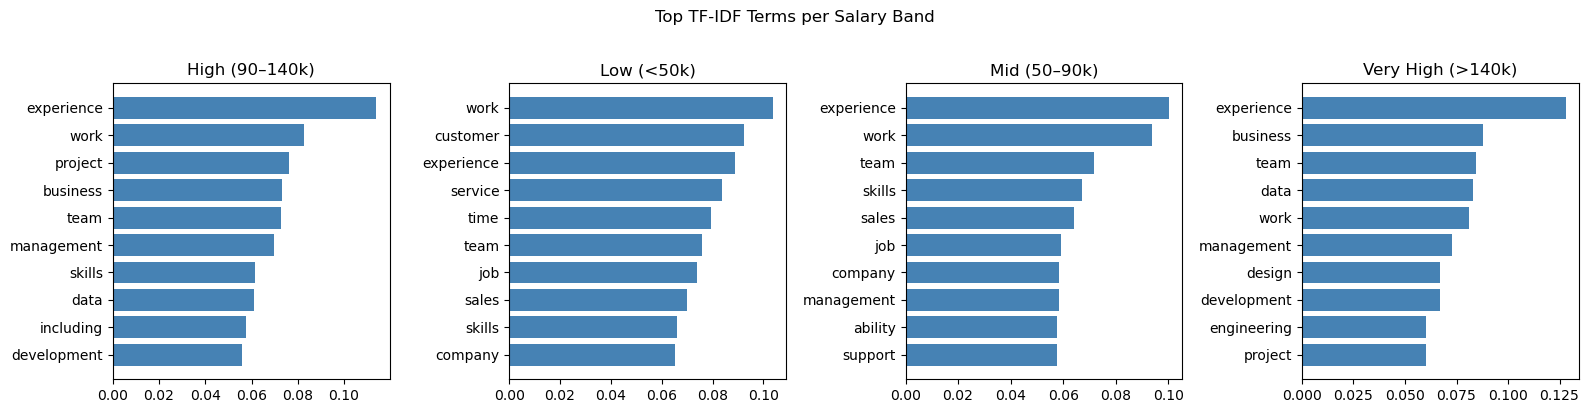

Saved: docs/figures/04_tfidf_per_band.png


In [11]:
# Top keywords per salary band
bands = df['salary_band'].dropna().unique()
fig, axes = plt.subplots(1, len(bands), figsize=(16, 4))

for ax, band in zip(axes, sorted(bands)):
    mask = df['salary_band'] == band
    band_matrix = tfidf_matrix[mask]
    band_means = np.asarray(band_matrix.mean(axis=0)).flatten()
    top = band_means.argsort()[-10:][::-1]
    ax.barh([feature_names[i] for i in top], band_means[top], color='steelblue')
    ax.set_title(f'{band}')
    ax.invert_yaxis()

plt.suptitle('Top TF-IDF Terms per Salary Band', y=1.02)
plt.tight_layout()
plt.savefig('../docs/figures/04_tfidf_per_band.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: docs/figures/04_tfidf_per_band.png')

## 4. Approach B — LLM Prompt Extraction (OpenAI GPT-4o-mini)
We use OpenAI to extract structured fields from job descriptions: domain, seniority, skills, remote flag. Two prompt strategies are compared.

In [13]:
from openai import OpenAI

client = OpenAI()  # reads OPENAI_API_KEY from environment

PROMPT_V1 = """You are a structured data extractor. Given a job description, extract the following fields.
Respond ONLY with valid JSON, no explanation, no markdown.

Fields:
- domain: one of [tech, finance, healthcare, marketing, operations, education, other]
- seniority_implied: one of [junior, mid, senior, lead, unknown]
- top_skills: list of up to 5 key skills mentioned
- remote_friendly: true or false

Job description:
{description}
"""

PROMPT_V2 = """Analyze this job posting and return JSON with these exact keys:
domain, seniority_implied, top_skills (array), remote_friendly (bool).

domain values: tech, finance, healthcare, marketing, operations, education, other
seniority values: junior, mid, senior, lead, unknown

Be concise. JSON only.

Posting: {description}
"""

def extract_with_prompt(description, prompt_template):
    try:
        response = client.chat.completions.create(
            model='gpt-4o-mini',
            messages=[{'role': 'user', 'content': prompt_template.format(description=str(description)[:1500])}],
            max_tokens=300,
            temperature=0
        )
        return json.loads(response.choices[0].message.content.strip())
    except:
        return {'domain': 'other', 'seniority_implied': 'unknown', 'top_skills': [], 'remote_friendly': False}

# Test on one example
sample = df['description'].iloc[0]
result = extract_with_prompt(sample, PROMPT_V1)
print('Sample LLM extraction (Prompt V1):')
print(json.dumps(result, indent=2))

Sample LLM extraction (Prompt V1):
{
  "domain": "marketing",
  "seniority_implied": "mid",
  "top_skills": [
    "graphic design",
    "Adobe Creative Cloud",
    "Microsoft Office Suite",
    "communication",
    "organization"
  ],
  "remote_friendly": false
}


## 5. Prompt Comparison (V1 vs V2)
We test both prompt strategies on 10 samples and compare output consistency.

In [15]:
test_samples = df['description'].head(10).tolist()
results_v1, results_v2 = [], []

for desc in test_samples:
    results_v1.append(extract_with_prompt(desc, PROMPT_V1))
    results_v2.append(extract_with_prompt(desc, PROMPT_V2))

domain_agree    = sum(r1['domain'] == r2['domain'] for r1, r2 in zip(results_v1, results_v2))
seniority_agree = sum(r1['seniority_implied'] == r2['seniority_implied'] for r1, r2 in zip(results_v1, results_v2))
print(f'Domain agreement:    {domain_agree}/10 ({domain_agree*10}%)')
print(f'Seniority agreement: {seniority_agree}/10 ({seniority_agree*10}%)')

comparison = pd.DataFrame({
    'prompt_v1_domain':     [r['domain'] for r in results_v1],
    'prompt_v2_domain':     [r['domain'] for r in results_v2],
    'prompt_v1_seniority':  [r['seniority_implied'] for r in results_v1],
    'prompt_v2_seniority':  [r['seniority_implied'] for r in results_v2],
})
comparison.to_csv('../docs/nlp_prompt_comparison.csv', index=False)
print('Saved: docs/nlp_prompt_comparison.csv')
comparison

Domain agreement:    6/10 (60%)
Seniority agreement: 1/10 (10%)
Saved: docs/nlp_prompt_comparison.csv


,prompt_v1_domain,prompt_v2_domain,prompt_v1_seniority,prompt_v2_seniority
0,marketing,other,mid,unknown
1,healthcare,other,mid,unknown
2,other,other,mid,unknown
3,other,other,senior,unknown
4,other,other,mid,unknown
5,other,other,junior,unknown
6,other,other,unknown,unknown
7,operations,other,mid,unknown
8,operations,other,mid,unknown
9,other,other,junior,unknown


## 6. Extract LLM Features for Full Dataset (500 rows)
Using the better prompt (V1) on 500 rows to keep API cost low.

In [17]:
SAMPLE_SIZE = 500
df_sample = df.head(SAMPLE_SIZE).copy()

print(f'Extracting LLM features for {SAMPLE_SIZE} rows...')
llm_features = []
for i, row in df_sample.iterrows():
    feats = extract_with_prompt(row['description'], PROMPT_V1)
    llm_features.append(feats)
    if len(llm_features) % 50 == 0:
        print(f'  {len(llm_features)}/{SAMPLE_SIZE} done')

df_llm = pd.DataFrame(llm_features, index=df_sample.index)
df_llm.head()

Extracting LLM features for 500 rows...
  50/500 done
  100/500 done
  150/500 done
  200/500 done
  250/500 done
  300/500 done
  350/500 done
  400/500 done
  450/500 done
  500/500 done


,domain,seniority_implied,top_skills,remote_friendly
0,marketing,mid,"[graphic design, Adobe Creative Cloud, Microso...",False
1,healthcare,mid,"[EMDR, trauma-informed care, psychological cou...",False
2,other,mid,[],False
3,other,senior,"[Estate Planning, Administration, Litigation, ...",False
4,other,mid,"[HVAC service, commercial equipment, industria...",False


In [18]:
# For the remaining rows (500+), use keyword-based fallback
def infer_domain(text):
    if not isinstance(text, str): return 'other'
    t = text.lower()
    if any(w in t for w in ['software','engineer','data','developer','tech','cloud','cyber','ml','ai']): return 'tech'
    if any(w in t for w in ['finance','account','bank','invest','audit','tax']): return 'finance'
    if any(w in t for w in ['health','nurse','medical','clinic','pharma','therapy']): return 'healthcare'
    if any(w in t for w in ['market','brand','social media','content','seo']): return 'marketing'
    if any(w in t for w in ['operat','supply chain','logistics','manufactur']): return 'operations'
    if any(w in t for w in ['teach','education','school','tutor','professor']): return 'education'
    return 'other'

def infer_seniority(title):
    if not isinstance(title, str): return 'unknown'
    t = title.lower()
    if any(w in t for w in ['senior','sr.','lead','principal','staff']): return 'senior'
    if any(w in t for w in ['junior','jr.','entry','intern']): return 'junior'
    if any(w in t for w in ['director','vp','chief','head of']): return 'lead'
    if any(w in t for w in ['manager','mid','ii','iii']): return 'mid'
    return 'unknown'

df_rest = df.iloc[SAMPLE_SIZE:].copy()
df_rest['domain']           = df_rest['title'].apply(infer_domain)
df_rest['seniority_implied'] = df_rest['title'].apply(infer_seniority)
df_rest['top_skills']       = [[] for _ in range(len(df_rest))]
df_rest['remote_friendly']  = False

# Merge LLM sample + keyword-inferred rest
df_with_llm = pd.concat([
    df_sample.join(df_llm[['domain','seniority_implied','top_skills','remote_friendly']]),
    df_rest
])

df_with_llm.to_csv('../data/processed/job_postings_with_llm_features.csv', index=False)
print(f'Saved {len(df_with_llm)} rows to data/processed/job_postings_with_llm_features.csv')

Saved 26866 rows to data/processed/job_postings_with_llm_features.csv


In [19]:
# Save TF-IDF and SVD artifacts
with open('../src/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
with open('../src/svd.pkl', 'wb') as f:
    pickle.dump(svd, f)

print('Saved: src/tfidf_vectorizer.pkl')
print('Saved: src/svd.pkl')

Saved: src/tfidf_vectorizer.pkl
Saved: src/svd.pkl
